# Notebook 01b — EDA phần 2: Câu hỏi và đáp án

Notebook 01a khảo sát kho văn bản. Notebook này khảo sát phía còn lại:
**câu hỏi** và **đáp án**, cùng mức độ khớp giữa hai phía.

| Mục | Câu hỏi khảo sát |
| --- | --- |
| 1 | Câu hỏi phân bố giữa các nhóm ra sao |
| 2 | Câu hỏi có cấu trúc gì |
| 3 | Câu hỏi và văn bản có viết cùng một kiểu không |
| 4 | Mỗi câu hỏi có bao nhiêu đáp án |
| 5 | Trùng lặp ảnh hưởng tới đáp án thế nào |
| 6 | Yếu tố thời gian thể hiện ra sao |
| 7 | Cách chấm điểm có điểm gì cần lưu ý |
| 8 | Tổng hợp toàn bộ EDA |

## 0. Chuẩn bị

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import re
import hashlib

import numpy as np
import matplotlib.pyplot as plt

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
assert DATA.is_dir(), f"Dataset not found at {DATA}"
domains = sorted(p.name for p in DATA.iterdir() if p.is_dir())


def read_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


queries = {d: read_jsonl(DATA / d / "examples_train.jsonl") for d in domains}
print(f"Loaded {sum(len(v) for v in queries.values()):,} train queries "
      f"from {len(domains)} domains")

Loaded 1,211 train queries from 13 domains


In [2]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        # Subtitle sits just above the axes; the title is offset further up in
        # POINTS, not axes fractions, so the gap holds at any figure size.
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    # The gridline already marks the scale; the spine it runs into is noise.
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

## 1. Phân bố câu hỏi giữa các nhóm

Biểu đồ dưới đối chiếu hai đại lượng cho từng nhóm: **tỉ lệ câu hỏi** nhóm đó
chiếm, và **trọng số** nhóm đó có trong điểm cuối. Vì điểm được tính trung bình
theo nhóm, trọng số luôn bằng nhau.

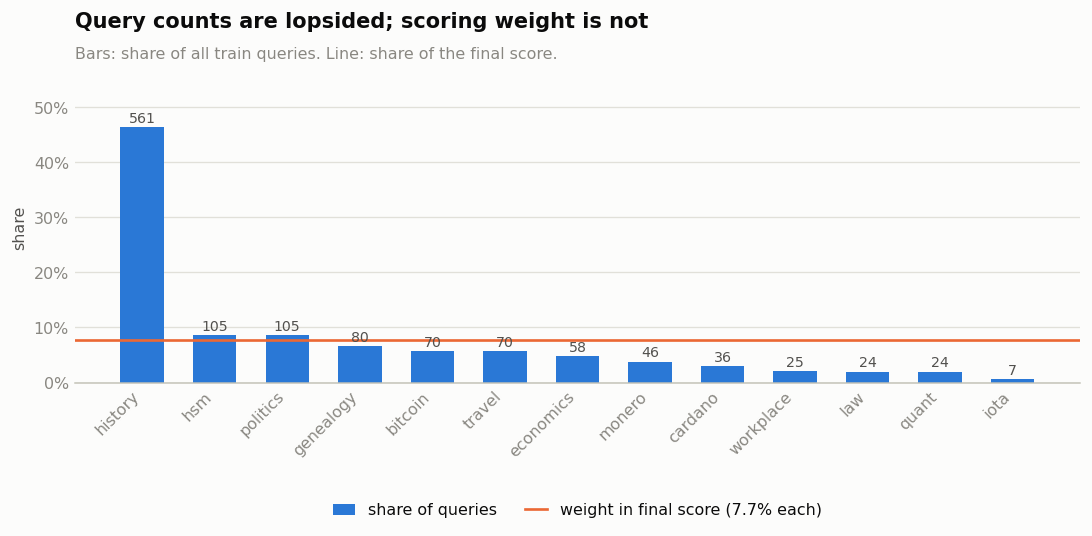

Largest : history       561 queries  ( 46.3% of queries, 7.7% of score)
Smallest: iota            7 queries  (  0.6% of queries, 7.7% of score)
Ratio   : 80x


In [3]:
counts = {d: len(queries[d]) for d in domains}
order = sorted(domains, key=lambda d: counts[d], reverse=True)
values = [counts[d] for d in order]
total = sum(values)

share_queries = [100 * v / total for v in values]
share_score = 100 / len(order)

fig, ax = plt.subplots(figsize=(9.2, 5.0))
x = np.arange(len(order))
bars = ax.bar(x, share_queries, width=0.6, color=BLUE, label="share of queries")

# The equal-weight line is the comparison the chart exists to make
ax.axhline(share_score, color=ORANGE, linewidth=1.6, zorder=3,
           label=f"weight in final score ({share_score:.1f}% each)")

for i, (pct, n) in enumerate(zip(share_queries, values)):
    ax.text(i, pct + 0.9, f"{n}", ha="center", fontsize=8.5, color=INK_SOFT)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylim(0, max(share_queries) * 1.22)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")

finish(ax,
       "Query counts are lopsided; scoring weight is not",
       subtitle="Bars: share of all train queries. Line: share of the final score.",
       ylabel="share")

# Bars lead the legend: they are the subject, the line is the reference
handles, labels = ax.get_legend_handles_labels()
pairs = sorted(zip(handles, labels), key=lambda hl: "share" not in hl[1])
ax.legend([h for h, _ in pairs], [l for _, l in pairs],
          frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.34),
          ncol=2, fontsize=9.5, handlelength=1.4, columnspacing=1.8)
plt.tight_layout()
plt.show()

print(f"Largest : {order[0]:<12}{values[0]:>5} queries  "
      f"({share_queries[0]:>5.1f}% of queries, {share_score:.1f}% of score)")
print(f"Smallest: {order[-1]:<12}{values[-1]:>5} queries  "
      f"({share_queries[-1]:>5.1f}% of queries, {share_score:.1f}% of score)")
print(f"Ratio   : {values[0] / values[-1]:.0f}x")

> ### Vấn đề 3 — Mất cân bằng giữa các nhóm
>
> Cột cho thấy tỉ lệ câu hỏi, đường ngang cho thấy trọng số trong điểm cuối.
> Khoảng cách giữa hai thứ chính là vấn đề.
>
> Hệ quả trực tiếp:
>
> - Nhóm lớn nhất chiếm gần một nửa số câu hỏi nhưng chỉ đóng góp 7,7% điểm.
> - Một cải tiến chỉ có tác dụng trên nhóm lớn sẽ gần như **không làm tăng điểm**.
> - Ngược lại, cải tiến trên nhóm nhỏ có tác động lớn hơn nhiều so với cảm nhận
>   thông thường.
>
> Khi so sánh hai phương pháp, phép kiểm định thống kê phải **tính theo nhóm**,
> không gộp toàn bộ câu hỏi vào một rổ.

## 2. Cấu trúc câu hỏi

Mỗi câu hỏi là một bài đăng diễn đàn gồm tiêu đề ngắn và phần thân dài.
Phần này đo tỉ lệ độ dài giữa hai thành phần.

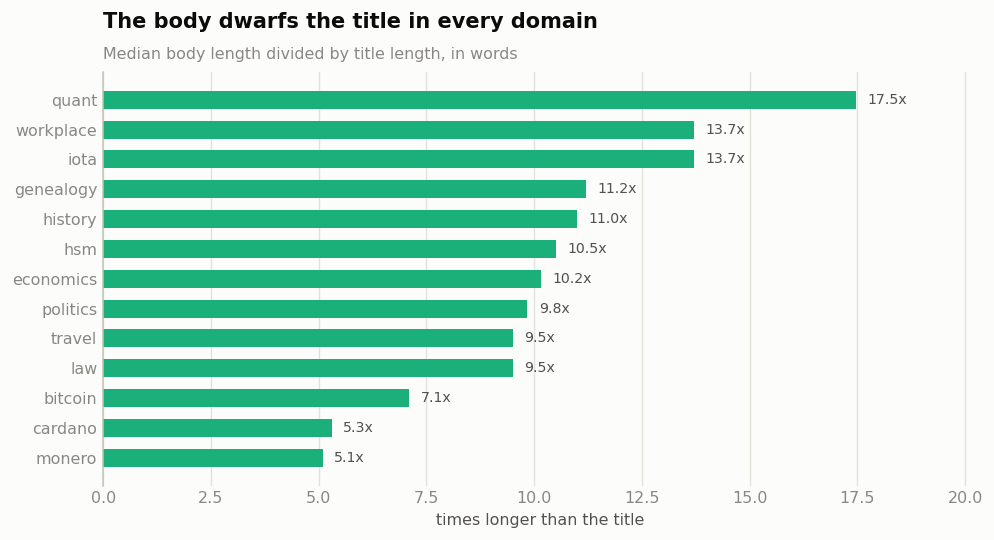

In [4]:
RE_TAG = re.compile(r"<[^>]+>")


def split_title_body(text):
    """The title is everything before the first <p> tag."""
    match = re.search(r"<p>", text)
    if not match:
        return text, ""
    return text[:match.start()], text[match.start():]


ratios = {}
for d in domains:
    per_query = []
    for record in queries[d]:
        title, body = split_title_body(record["query"])
        n_title = len(RE_TAG.sub(" ", title).split())
        n_body = len(RE_TAG.sub(" ", body).split())
        if n_title:
            per_query.append(n_body / n_title)
    ratios[d] = per_query

ordered = sorted(domains, key=lambda d: np.median(ratios[d]))
medians = [np.median(ratios[d]) for d in ordered]

fig, ax = plt.subplots(figsize=(8.4, 4.6))
bars = ax.barh(range(len(ordered)), medians, color=TEAL, height=0.6)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered)
label_bars(ax, bars, medians, fmt="{:.1f}x")
ax.set_xlim(0, max(medians) * 1.16)

finish(ax,
       "The body dwarfs the title in every domain",
       subtitle="Median body length divided by title length, in words",
       xlabel="times longer than the title", grid_axis="x")
plt.tight_layout()
plt.show()

Tiêu đề thường chứa **trọn vẹn nhu cầu thông tin** ở dạng cô đọng, còn phần thân
bổ sung bối cảnh và thường lặp lại ý đã nêu.

Đây là một hướng đáng thử nghiệm về sau: đưa vào hệ thống truy hồi **cả bài**,
**chỉ tiêu đề**, hay **tiêu đề được nhân trọng số**.

## 3. Câu hỏi và văn bản có cùng định dạng không?

Câu hỏi lấy từ diễn đàn nên còn giữ mã HTML. Văn bản trong kho đã được làm sạch.
Phần này đo mức chênh lệch.

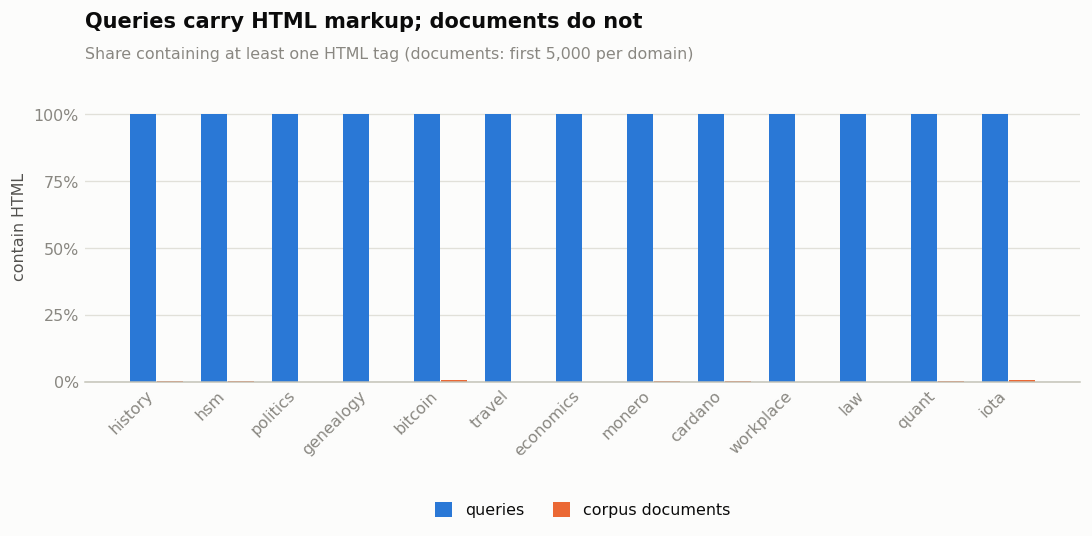

Mean across domains - queries : 100.0%
Mean across domains - documents:   0.2%


In [5]:
SAMPLE = 5000   # documents sampled per domain, for speed

html_in_queries = {}
html_in_docs = {}

for d in domains:
    with_tag = sum(1 for r in queries[d] if RE_TAG.search(r["query"]))
    html_in_queries[d] = 100 * with_tag / len(queries[d])

    seen = hits = 0
    with open(DATA / d / "documents.jsonl", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            seen += 1
            if RE_TAG.search(json.loads(line)["content"] or ""):
                hits += 1
            if seen >= SAMPLE:
                break
    html_in_docs[d] = 100 * hits / max(seen, 1)

fig, ax = plt.subplots(figsize=(9.2, 5.0))
x = np.arange(len(order))
ax.bar(x - 0.19, [html_in_queries[d] for d in order], width=0.36,
       color=BLUE, label="queries")
ax.bar(x + 0.19, [html_in_docs[d] for d in order], width=0.36,
       color=ORANGE, label="corpus documents")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylim(0, 116)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")

finish(ax,
       "Queries carry HTML markup; documents do not",
       subtitle=f"Share containing at least one HTML tag "
                f"(documents: first {SAMPLE:,} per domain)",
       ylabel="contain HTML")
legend_below(ax, ncol=2, y=-0.34)
plt.tight_layout()
plt.show()

print(f"Mean across domains - queries : {np.mean(list(html_in_queries.values())):>5.1f}%")
print(f"Mean across domains - documents: {np.mean(list(html_in_docs.values())):>5.1f}%")

In [6]:
# What do those tags become once the text is split on non-alphanumerics?
MARKUP_WORDS = {"p", "a", "href", "http", "https", "br", "li", "ul", "code",
                "strong", "em", "div", "span", "nbsp", "quot", "amp", "rel",
                "nofollow", "noreferrer", "blockquote", "pre", "img", "src"}

found = Counter()
token_total = 0
for d in domains:
    for record in queries[d]:
        tokens = re.findall(r"[A-Za-z0-9]+", record["query"].lower())
        token_total += len(tokens)
        found.update(t for t in tokens if t in MARKUP_WORDS)

print("Words produced by HTML markup, across all train queries:\n")
print(f"  {'word':<14}{'occurrences':>13}")
print("  " + "-" * 27)
for word, n in found.most_common(10):
    print(f"  {word:<14}{n:>13,}")
print(f"\nTotal: {sum(found.values()):,} of {token_total:,} query tokens "
      f"({100 * sum(found.values()) / token_total:.1f}%)")

Words produced by HTML markup, across all train queries:

  word            occurrences
  ---------------------------
  p                     9,523
  a                     7,263
  https                 1,744
  href                  1,605
  quot                  1,526
  rel                   1,475
  noreferrer            1,452
  li                    1,199
  nofollow                980
  strong                  922

Total: 31,229 of 246,533 query tokens (12.7%)


> ### Vấn đề 4 — Hai phía không cùng định dạng
>
> Gần như **100% câu hỏi** chứa mã HTML, trong khi **gần 0% văn bản** trong kho
> chứa mã này.
>
> Nếu tách từ theo cách thông thường, các thẻ HTML biến thành những từ như
> `p`, `href`, `http`, `li`. Đây là những từ chỉ xuất hiện ở phía câu hỏi, nên
> chúng **không thể khớp đúng** với bất kỳ văn bản nào — chỉ tạo nhiễu.
>
> Bước tiền xử lý cần loại bỏ chúng.

## 4. Số đáp án của mỗi câu hỏi

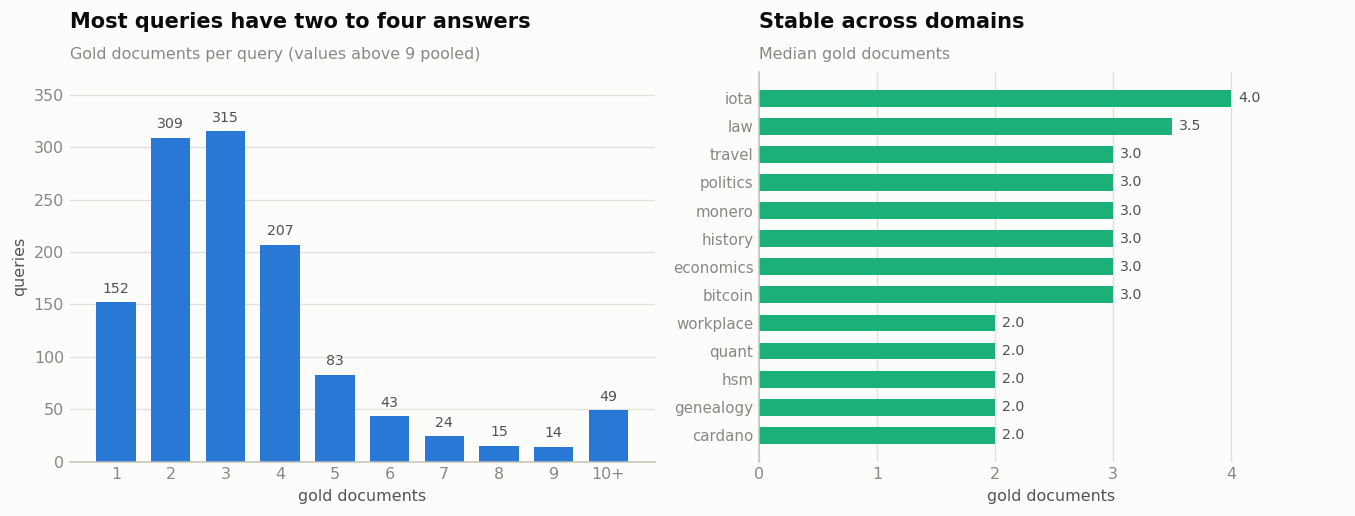

Median : 3
Mean   : 3.6
Range  : 1 to 39

Tail beyond 9, exact counts:
   gold docs   queries
          10         7
          11        11
          12         4
          13         3
          14         3
          15         3
          16         2
          17         2
          18         1
          19         2
          20         4
          21         2
          23         2
          28         1
          29         1
          39         1
       total        49  (4.0% of queries)


In [7]:
gold_counts = {d: [len(set(r["gold_ids"])) for r in queries[d]] for d in domains}
all_counts = [n for v in gold_counts.values() for n in v]

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4))

# The raw distribution runs out to a very long tail, which makes a bar per
# value unreadable. Values 1-9 are kept exact; everything above is pooled.
CAP = 9
buckets = list(range(1, CAP + 1)) + [f"{CAP + 1}+"]
heights = [sum(1 for n in all_counts if n == k) for k in range(1, CAP + 1)]
heights.append(sum(1 for n in all_counts if n > CAP))

bars = axes[0].bar(range(len(buckets)), heights, width=0.72, color=BLUE)
label_bars(axes[0], bars, heights, horizontal=False, pad=0.02)
axes[0].set_ylim(0, max(heights) * 1.18)
axes[0].set_xticks(range(len(buckets)))
axes[0].set_xticklabels(buckets)
finish(axes[0], "Most queries have two to four answers",
       subtitle=f"Gold documents per query (values above {CAP} pooled)",
       xlabel="gold documents", ylabel="queries")

ordered2 = sorted(domains, key=lambda d: np.median(gold_counts[d]))
medians2 = [np.median(gold_counts[d]) for d in ordered2]
bars2 = axes[1].barh(range(len(ordered2)), medians2, color=TEAL, height=0.6)
axes[1].set_yticks(range(len(ordered2)))
axes[1].set_yticklabels(ordered2, fontsize=9)
label_bars(axes[1], bars2, medians2, fmt="{:.1f}")
axes[1].set_xlim(0, max(medians2) * 1.24)   # room for the value labels
finish(axes[1], "Stable across domains", subtitle="Median gold documents",
       xlabel="gold documents", grid_axis="x")

plt.tight_layout()
plt.show()

print(f"Median : {np.median(all_counts):.0f}")
print(f"Mean   : {np.mean(all_counts):.1f}")
print(f"Range  : {min(all_counts)} to {max(all_counts)}")

# Exact counts, including the tail the chart pools into one bar
tail = Counter(n for n in all_counts if n > CAP)
if tail:
    print(f"\nTail beyond {CAP}, exact counts:")
    print(f"  {'gold docs':>10}{'queries':>10}")
    for k in sorted(tail):
        print(f"  {k:>10}{tail[k]:>10}")
    print(f"  {'total':>10}{sum(tail.values()):>10}"
          f"  ({100 * sum(tail.values()) / len(all_counts):.1f}% of queries)")

Mỗi câu hỏi thường có vài đáp án, và con số này khá ổn định giữa các nhóm.

Điều này có ý nghĩa với cách chấm điểm: nDCG@10 lấy điểm thực tế chia cho **điểm
tối đa có thể đạt**, mà điểm tối đa phụ thuộc số đáp án. Vì vậy số đáp án khác
nhau **không làm lệch** việc so sánh giữa các câu hỏi.

## 5. Trùng lặp ảnh hưởng tới đáp án ra sao

Notebook 01a cho thấy khoảng 30% kho văn bản là bản sao. Phần này kiểm tra điều
đó ảnh hưởng thế nào tới các văn bản là đáp án.

Phép thử: nếu khử trùng lặp bằng cách đơn giản nhất — **giữ bản xuất hiện đầu
tiên, bỏ các bản còn lại** — thì có bao nhiêu đáp án bị mất?

In [8]:
# Reads full corpora, so this is limited to a few domains for speed.
CHECK_DOMAINS = ["iota", "law", "quant"]

print(f"{'domain':<10}{'gold':>7}{'with copies':>14}{'lost if naive dedup':>22}")
print("-" * 54)

for d in CHECK_DOMAINS:
    hash_of = {}
    order_seen = []
    with open(DATA / d / "documents.jsonl", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                record = json.loads(line)
                hash_of[record["id"]] = hashlib.sha1(
                    (record["content"] or "").encode()).hexdigest()
                order_seen.append(record["id"])

    groups = defaultdict(list)
    for doc_id in order_seen:
        groups[hash_of[doc_id]].append(doc_id)
    kept = {members[0] for members in groups.values()}

    gold = set()
    with open(DATA / d / "qrels_train.txt", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                qid, _, doc_id, relevance = line.split()
                if int(relevance) > 0:
                    gold.add(doc_id)

    with_copies = sum(1 for g in gold if len(groups[hash_of[g]]) > 1)
    lost = sum(1 for g in gold if g not in kept)

    print(f"{d:<10}{len(gold):>7}{with_copies:>10} ({100*with_copies/len(gold):>3.0f}%)"
          f"{lost:>14} ({100*lost/len(gold):>3.0f}%)")

domain       gold   with copies   lost if naive dedup
------------------------------------------------------
iota           29         2 (  7%)             1 (  3%)
law            77         2 (  3%)             1 (  1%)
quant          61         4 (  7%)             2 (  3%)


> ### Vấn đề 5 — Khử trùng lặp có thể làm mất đáp án
>
> Một số văn bản là đáp án cũng có bản sao trong kho. Nếu khử trùng lặp bằng
> cách giữ bản đầu tiên, bản được giữ lại có thể **không phải** bản được ghi
> trong danh sách đáp án — và đáp án đó coi như bị mất.
>
> Tỉ lệ mất khoảng 1–3%, không lớn nhưng **âm thầm**: hệ thống vẫn chạy, file
> kết quả vẫn hợp lệ, điểm chỉ thấp hơn một chút mà không có dấu hiệu báo lỗi.
>
> Nếu khử trùng lặp, cần **ánh xạ kết quả ngược lại** tất cả các mã có cùng nội
> dung, thay vì loại bỏ hẳn.

## 6. Yếu tố thời gian

File `guidance_train.jsonl` chứa chú thích của ban tổ chức về mặt thời gian cho
từng câu hỏi. File này không bắt buộc dùng, nhưng cho thấy **điều gì khiến bài
toán này khác một bài truy hồi thông thường**.

In [9]:
guidance = {}
for d in domains:
    path = DATA / d / "guidance_train.jsonl"
    if path.exists():
        guidance[d] = {r["id"]: r for r in read_jsonl(path)}

sample = guidance["iota"][queries["iota"][0]["id"]]
print("Fields:", list(sample.keys()))
print()
print(json.dumps(sample["query_guidance"], indent=2, ensure_ascii=False)[:750])

Fields: ['id', 'query_guidance', 'gold_passage_annotations']

{
  "expected_granularity": "duration",
  "is_temporal_query": true,
  "key_time_anchors": [
    "testnet"
  ],
  "quality_checks": [
    "cross-check technical documentation with community insights",
    "verify testnet-specific policies from authoritative sources"
  ],
  "query_summary": "The query seeks to determine the duration of Zero Value Transactions on the Tangle and methods to preserve them.",
  "query_temporal_events": [],
  "query_temporal_signals": [
    "how long",
    "last"
  ],
  "retrieval_plan": [
    {
      "action": "Search for official documentation or whitepapers on the Tangle and Zero Value Transactions.",
      "gold_ids": [
        "iota/d3459a40_0171.txt",
        "iota/84765dc2_0172.txt"
      ],
      "step": 1


In [10]:
granularity = Counter()
temporal = Counter()
anchor_counts = []

for records in guidance.values():
    for record in records.values():
        g = record.get("query_guidance", {})
        granularity[g.get("expected_granularity", "unknown")] += 1
        temporal[bool(g.get("is_temporal_query"))] += 1
        anchor_counts.append(len(g.get("key_time_anchors", [])))

n_total = sum(temporal.values())
print(f"Marked as temporal   : {temporal[True]:,} of {n_total:,} "
      f"({100 * temporal[True] / n_total:.1f}%)")
print(f"Mean time anchors    : {np.mean(anchor_counts):.1f} per query")
print()

# The organisers' granularity labels are free text with a long tail of rare
# values, so a bar per label would be a very tall chart carrying little. A
# table shows the same thing, exactly, in a fraction of the space.
n_labels = len(granularity)
n_queries = sum(granularity.values())

print(f"Temporal granularity, {n_labels} distinct values "
      f"over {n_queries:,} queries\n")
print(f"  {'granularity':<26}{'queries':>9}{'share':>9}{'cumulative':>13}")
print("  " + "-" * 55)

running = 0
for label, n in granularity.most_common():
    running += n
    print(f"  {label:<26}{n:>9,}{100 * n / n_queries:>8.1f}%"
          f"{100 * running / n_queries:>12.1f}%")

top = granularity.most_common(3)
covered = sum(n for _, n in top)
print(f"\n  Top 3 values cover {100 * covered / n_queries:.1f}% of queries.")

Marked as temporal   : 1,150 of 1,211 (95.0%)
Mean time anchors    : 2.3 per query

Temporal granularity, 93 distinct values over 1,211 queries

  granularity                 queries    share   cumulative
  -------------------------------------------------------
  year                            363    30.0%        30.0%
  decade                          138    11.4%        41.4%
  century                         132    10.9%        52.3%
  date                            117     9.7%        61.9%
  period                          102     8.4%        70.4%
  month                            51     4.2%        74.6%
                                   40     3.3%        77.9%
  era                              25     2.1%        79.9%
  duration                         20     1.7%        81.6%
  hours                            17     1.4%        83.0%
  day                              15     1.2%        84.2%
  days                             15     1.2%        85.5%
  broad period   

Phần lớn câu hỏi được đánh dấu là **có yếu tố thời gian**, và mỗi câu hỏi thường
gắn với một vài mốc thời gian cụ thể.

Điểm khó nằm ở chỗ: phương pháp truy hồi dựa trên từ vựng chỉ so được **từ ngữ**.
Một văn bản nói đúng chủ đề nhưng mô tả tình trạng ở thời điểm khác vẫn dùng gần
như cùng một bộ từ vựng, nên rất khó phân biệt.

## 7. Điểm cần lưu ý khi chấm điểm

Mã chấm điểm chính thức (`RETECO/starter_kit/scorer.py`, dòng 94) chọn câu hỏi
được chấm như sau:

```python
qids = [q for q in gold if q in run]
```

Nghĩa là chỉ những câu hỏi **có mặt trong cả đáp án lẫn file kết quả** mới được
tính điểm. Câu hỏi mà hệ thống không trả về kết quả nào sẽ bị **loại khỏi phép
tính trung bình**, chứ không bị tính 0 điểm.

In [11]:
def official_average(per_query_scores, submitted):
    """Replicates the official rule: only submitted queries are averaged."""
    scored = [s for qid, s in per_query_scores.items() if qid in submitted]
    return (sum(scored) / len(scored)) if scored else 0.0


per_query = {"q1": 0.9, "q2": 0.8, "q3": 0.0, "q4": 0.0, "q5": 0.0}

answers_all = official_average(per_query, set(per_query))
answers_easy = official_average(per_query, {"q1", "q2"})

print("System A - answers all 5 queries")
print(f"  score = {answers_all:.4f}    num_topics = 5")
print()
print("System B - answers only the 2 easy ones, skips the 3 hard ones")
print(f"  score = {answers_easy:.4f}    num_topics = 2")
print()
print(f"System B scores {answers_easy / answers_all:.1f}x higher "
      f"while doing strictly less work.")

System A - answers all 5 queries
  score = 0.3400    num_topics = 5

System B - answers only the 2 easy ones, skips the 3 hard ones
  score = 0.8500    num_topics = 2

System B scores 2.5x higher while doing strictly less work.


> ### Vấn đề 6 — Điểm số có thể gây hiểu nhầm
>
> Ví dụ trên cho thấy một hệ thống trả lời **ít câu hỏi hơn** lại có thể đạt
> **điểm cao hơn**, chỉ vì những câu khó bị loại khỏi phép tính.
>
> Đây không phải lỗi của bộ chấm điểm — đó là quy ước chuẩn trong lĩnh vực truy
> hồi thông tin. Nhưng nó tạo ra một cái bẫy khi tự đánh giá.
>
> **Quy tắc cần tuân thủ:** mọi bảng kết quả phải ghi kèm `num_topics` (số câu
> hỏi thực sự được chấm) bên cạnh điểm số. Hai con số điểm chỉ so sánh được với
> nhau khi `num_topics` bằng nhau.

## 8. Tổng hợp toàn bộ EDA

### Các vấn đề của bộ dữ liệu

| # | Vấn đề | Mức độ | Xử lý |
| --- | --- | --- | --- |
| 1 | ~30% văn bản trùng lặp, có nhóm trên 60% | Cao | Khử trùng lặp có ánh xạ ngược, không loại bỏ hẳn |
| 2 | Mã tài liệu để lộ đâu là đáp án | Nghiêm trọng | Chỉ ghi nhận trong báo cáo, **không sử dụng** |
| 3 | Số câu hỏi giữa các nhóm chênh ~80 lần | Cao | Mọi phép so sánh phải tính theo nhóm |
| 4 | Câu hỏi có HTML, văn bản thì không | Trung bình | Loại thẻ HTML ở bước tiền xử lý |
| 5 | Khử trùng lặp ngây thơ làm mất 1–3% đáp án | Thấp nhưng âm thầm | Ánh xạ kết quả sang mọi mã cùng nội dung |
| 6 | Câu hỏi không có kết quả bị loại khỏi trung bình | Cao | Luôn ghi kèm `num_topics` |

### Những hướng đáng thử nghiệm

| Hướng | Xuất phát từ quan sát |
| --- | --- |
| Loại bỏ thẻ HTML và từ dừng khỏi câu hỏi | Mục 3 — hai phía không cùng định dạng |
| Thử dùng riêng tiêu đề, hoặc nhân trọng số tiêu đề | Mục 2 — phần thân dài gấp nhiều lần tiêu đề |
| Khử trùng lặp trước khi xử lý nặng | Mục 5 và Notebook 01a — tiết kiệm tính toán |
| Xếp hạng lại bằng mô hình đọc cả câu hỏi và văn bản | Mục 6 — yếu tố thời gian cần hiểu ngữ cảnh |

### Nguyên tắc đánh giá rút ra

1. So sánh hai phương pháp bằng phép kiểm định **tính theo nhóm**, không gộp
   chung câu hỏi.
2. Luôn báo cáo `num_topics` cùng với điểm.
3. Không kết luận từ kết quả của một nhóm đơn lẻ — các nhóm chênh nhau quá lớn.

**Tiếp theo:** xây dựng hệ thống cơ sở và tái lập mốc 0,0879.